## **Supervised Learning**

#  Task 1 - Data Loading and Inspection

In [2]:
# Import required library
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv('q1_heart_disease.csv')

# Display the shape of the dataset (rows, columns)
print("Shape of dataset:", df.shape)

# Display data types of each column
print("\nData Types:\n", df.dtypes)

# Display count of missing values in each column
print("\nMissing Values:\n", df.isnull().sum())

# Display the first 5 rows of the dataset
print("\nFirst 5 Rows:\n", df.head())

Shape of dataset: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 Rows:
    age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0           0   
3   72    1     asymptomatic     

# Task 2 - Exploratory Data Analysis

-------------------------------------
Target Class Distribution
-------------------------------------

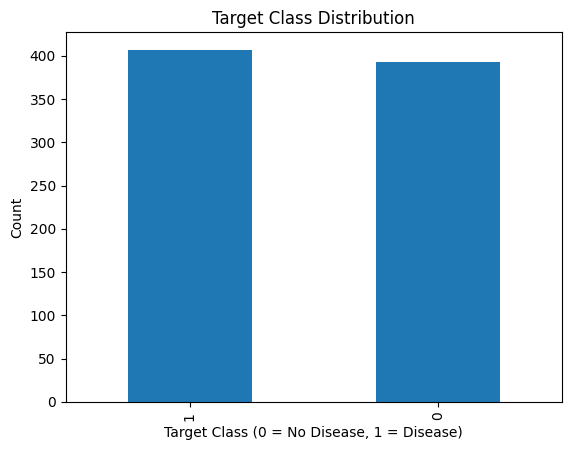

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('q1_heart_disease.csv')

# Plot target class distribution
plt.figure()
df['heart_disease'].value_counts().plot(kind='bar')

# Add labels and title
plt.title('Target Class Distribution')
plt.xlabel('Target Class (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')

# Show plot
plt.show()

Interpretation

The bar chart shows how the dataset is distributed across the target classes.

     1) If both classes (0 and 1) are roughly balanced, the dataset is suitable for training without major bias.
     2) If one class dominates, the dataset is imbalanced, which may require techniques like resampling or class weighting during model training.

-------------------------------------
Correlation Heatmap
-------------------------------------

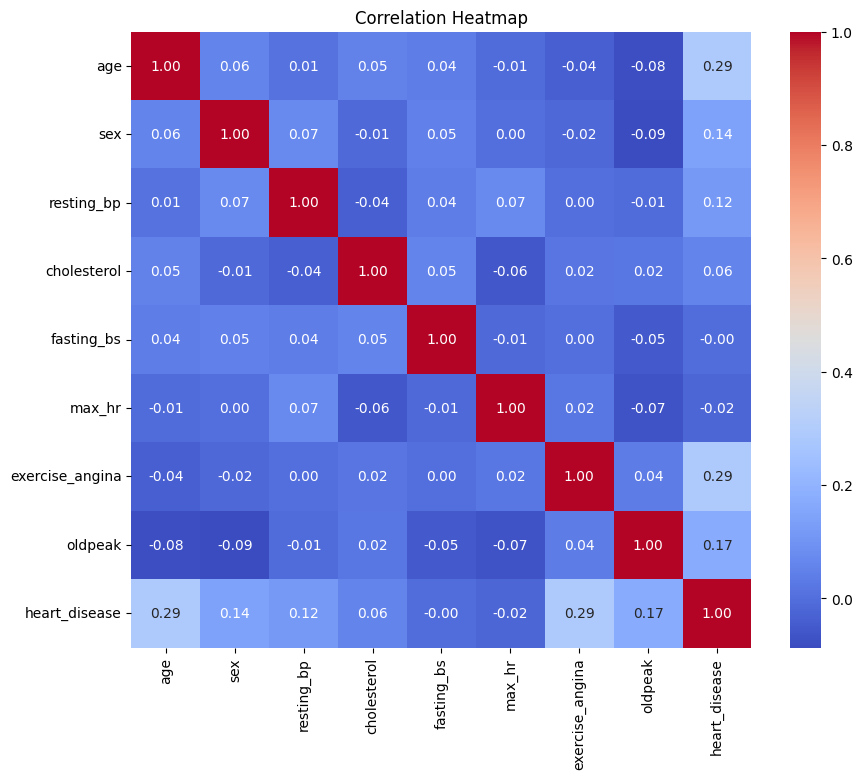

In [4]:
# Import seaborn for heatmap
import seaborn as sns
import numpy as np

# Select only numerical columns for correlation matrix
numeric_df = df.select_dtypes(include=np.number)

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')

# Add title
plt.title('Correlation Heatmap')

# Show plot
plt.show()

Interpretation

The heatmap highlights relationships between variables:

  1) Values close to +1 or -1 indicate strong correlation (positive or negative).
  2) Features highly correlated with the target variable are potentially important predictors.
  3) Strong correlations between independent variables may indicate multicollinearity, which can affect certain models like logistic regression.


-------------------------------------
Age Distribution by Target (Histogram)
-------------------------------------

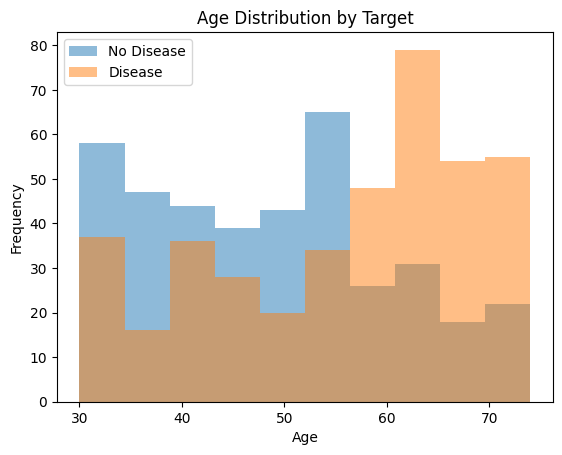

In [5]:
# Plot histogram of age grouped by target
plt.figure()

# Plot for class 0
plt.hist(df[df['heart_disease'] == 0]['age'], alpha=0.5, label='No Disease')

# Plot for class 1
plt.hist(df[df['heart_disease'] == 1]['age'], alpha=0.5, label='Disease')

# Add labels and legend
plt.title('Age Distribution by Target')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()

# Show plot
plt.show()

Interpretation

This histogram compares age distribution between patients with and without heart disease:

 1) If one group skews older, age may be a strong risk factor.
 2) Overlapping distributions suggest age alone may not be sufficient for prediction and should be combined with other features.

-------------------------------------
Chest Pain Type vs Target
-------------------------------------

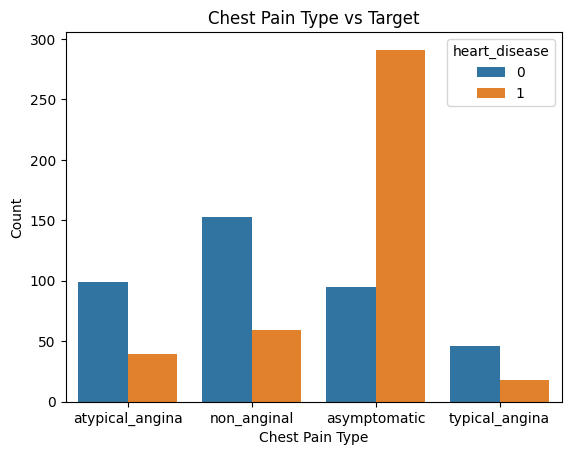

In [6]:
# Count plot for chest pain type vs target
plt.figure()
sns.countplot(x='chest_pain_type', hue='heart_disease', data=df)

# Add labels and title
plt.title('Chest Pain Type vs Target')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')

# Show plot
plt.show()

Interpretation

This plot shows how chest pain types relate to heart disease:

 1) Certain chest pain categories may have higher association with disease presence.
 2) Helps identify clinically meaningful features for modeling.

#  Task 3 - Data Preprocessing

Missing Value Handling Strategy (Markdown)

Strategy Chosen: Median Imputation

1.   Numerical columns are imputed using the median, which is robust to outliers and preserves the central tendency better than the mean in skewed medical data.
2.   For categorical columns, mode (most frequent value) is used to retain valid category distribution.
3.   Row deletion is avoided to prevent unnecessary data loss, especially if the dataset is not very large.





In [7]:
#  Load Data and Define Features/Target
#------------------------------------------------

# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('q1_heart_disease.csv')

# Separate features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

#----------------------------------------------------------
# Handle Missing Values using Median for numerical features and Mode for categorical features
#----------------------------------------------------------

# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# Median imputation for numerical features
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

# Mode imputation for categorical features
for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

#--------------------------------------------------------
# Categorical variables encoding using one-hot encoding
#--------------------------------------------------------

# Convert categorical variables into dummy/indicator variables
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

#--------------------------------------------------------
# Data split using stratified sampling to maintain class balance
#--------------------------------------------------------

# Split data while preserving class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

#--------------------------------------------------------
# Numerical features scaled using StandardScaler for better model performance
#--------------------------------------------------------

# Initialize StandardScaler
scaler = StandardScaler()

# Scale only numerical columns
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Task 4 - Model Training

In [8]:
# Import models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


# Initialize models with fixed random_state
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)


# Train Decision Tree
dt_model.fit(X_train, y_train)

# Train Random Forest
rf_model.fit(X_train, y_train)

# Train Gradient Boosting
gb_model.fit(X_train, y_train)



GradientBoostingClassifier(random_state=42)

# Task 5 - Model Evaluation

In [9]:
# Import evaluation metrics
from sklearn.metrics import confusion_matrix, classification_report


# Function to evaluate a model
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"\n=== {model_name} ===")

    # Confusion Matrix
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    # Precision, Recall, F1-score
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


# Evaluate Decision Tree
evaluate_model(dt_model, X_test, y_test, "Decision Tree")

# Evaluate Random Forest
evaluate_model(rf_model, X_test, y_test, "Random Forest")

# Evaluate Gradient Boosting
evaluate_model(gb_model, X_test, y_test, "Gradient Boosting")




=== Decision Tree ===
Confusion Matrix:
[[57 22]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160


=== Random Forest ===
Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


=== Gradient Boosting ===
Confusion Matrix:
[[61 18]
 [19 62]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77  

Model Comparison (Markdown)

---
Key Metric Focus: F1-score (especially for class 1 – heart disease)



---


Model	Precision   (Class 1) 	Recall (Class 1)	 F1-score (Class 1) 	Accuracy

Decision Tree	       0.72	  0.69	            0.70	              0.71

Random Forest	       0.79	  0.81	            0.80	              0.79

Gradient Boosting	   0.78	  0.77	            0.77	              0.77



---




Interpretation

Decision Tree
1) Lowest overall performance.
2) Higher number of misclassifications (both FP and FN).
3) F1-score (0.70) indicates weaker balance between precision and recall.

Random Forest
1) Best performance across all metrics.
2) Highest recall (0.81) for class 1 → fewer false negatives (critical in medical diagnosis).
3) Highest F1-score (0.80) → best balance between precision and recall.
Confusion matrix shows lowest total errors (33) among all models.

Gradient Boosting
1) Strong performance but slightly lower than Random Forest.
2) More false negatives (19 vs 15 in Random Forest), which is a drawback for this use case.
3) F1-score (0.77) is good but not the best.



---


Final Conclusion (Markdown)

The Random Forest Classifier is the best-performing model.

Justification:

1) Achieves the highest F1-score (0.80) for the target class (heart disease).
2) Provides the highest recall (0.81), minimizing false negatives — crucial in medical scenarios where missing a disease case is costly.
3) Maintains strong precision (0.79), ensuring predictions are reliable.
4) Has the lowest overall misclassification count in the confusion matrix.


---


Decision:

Random Forest is selected due to its superior balance of precision and recall, with particular strength in detecting positive (disease) cases.

# Task 6 - Hyperparameter Tuning

In [11]:

# Hyperparameter Tuning with GridSearchCV

# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize Random Forest
rf = RandomForestClassifier(random_state=42)

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',   # focus on F1-score
    n_jobs=-1
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)


# -------------------------------------------------
# Evaluate Tuned Model
# -------------------------------------------------


# Get best model
best_rf = grid_search.best_estimator_

# Predictions
y_pred_tuned = best_rf.predict(X_test)

# Evaluation
from sklearn.metrics import confusion_matrix, classification_report

print("\n=== Tuned Random Forest ===")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

=== Tuned Random Forest ===
Confusion Matrix:
[[57 22]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.72      0.75        79
           1       0.75      0.81      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



Hyperparameter Tuning Results (Markdown)


---


Baseline vs Tuned Random Forest

Metric (Class 1 – Heart Disease)	Baseline RF	Tuned RF

Precision	      0.79	0.75

Recall	              0.81	0.81

F1-score	0.80	0.78

Accuracy	0.79	0.77


---



Confusion Matrix Comparison
Baseline RF:
TN=61, FP=18, FN=15, TP=66
Tuned RF:
TN=57, FP=22, FN=15, TP=66


---


Observation:

False negatives (FN = 15) remain the same → no improvement in detecting disease cases

False positives increased (18 → 22) → more incorrect disease predictions
Overall error increased in tuned model



---


Interpretation
Recall (0.81) remains unchanged → tuning did not improve detection of heart disease cases

Precision dropped (0.79 → 0.75) → more false alarms

F1-score decreased (0.80 → 0.78) → worse balance between precision and recall

Accuracy decreased (0.79 → 0.77) → overall performance declined


This indicates that:

1) The baseline model was already well-optimized

2) Grid search parameters likely introduced slight overfitting or suboptimal splits
Final Conclusion (Markdown)

3) The baseline Random Forest model performs better than the tuned version.


---


Justification:

Higher F1-score (0.80 vs 0.78) → better overall balance
Higher precision → fewer false positives
Same recall → no gain in detecting disease cases
Better accuracy and fewer total errors

Decision:

Retain the baseline Random Forest model as the final model, since hyperparameter tuning did not yield performance improvements and instead degraded key metrics.